# TOPSIS recommendation validation

Валидация подбора автомобилей через TOPSIS на 12 синтетических кейсах.

Метрики:
- **NDCG@10** ≥ 0.85 — качество ранжирования vs ground truth.
- **Diversity@10** ≥ 4 — уникальных брендов в топ-10.
- **Coverage** ≥ 60% — доля каталога в любом топ-10.
- **Stability** ≥ 80% — устойчивость к колебанию весов ±5%.

Архитектура: `RecommendationService(strategy=TopsisStrategy(), filters=[...])`.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO / 'ml'))

from recommendation import (
    UserProfile, RecommendationService, TopsisStrategy, WeightedSumStrategy,
    TCOCalculator, load_seed, DEFAULT_CRITERIA, WEIGHT_PRESETS,
)
from recommendation.filters import build_filters_from_profile
from recommendation.decomposition import decompose

print('Imports OK')
print(f'Criteria: {[c.name for c in DEFAULT_CRITERIA]}')
print(f'Presets: {sorted(WEIGHT_PRESETS)}')

Imports OK
Criteria: ['tco_5y', 'purchase_price', 'reliability_score', 'depreciation_5y_pct', 'power_hp', 'cargo_volume_l']
Presets: ['balanced', 'business', 'cheapest', 'family', 'premium', 'student']


## 1. Загрузка seed + service init

In [2]:
seed = load_seed()
calc = TCOCalculator(seed)
service = RecommendationService(tco_calc=calc, strategy=TopsisStrategy())

catalog = seed['modifications'].copy()
print(f'Catalog: {len(catalog):,} modifications across {seed["models"]["id"].nunique()} models')

cases = pd.read_csv(REPO / 'ml' / 'data' / 'seed' / 'topsis_synthetic_cases.csv')
print(f'Synthetic cases: {len(cases)}')
cases[['case_id', 'description', 'budget_rub', 'weight_preset']]

Catalog: 875 modifications across 480 models
Synthetic cases: 12


,case_id,description,budget_rub,weight_preset
0,1,Студент-городской бюджет 1.5М,1500000,student
1,2,Семья 4 чел С-класс mass,2500000,family
2,3,Семья + дача кроссовер,3500000,balanced
3,4,Премиум седан Е,8000000,premium
4,5,Премиум SUV J_CROSS,12000000,premium
5,6,Off-road рамный SUV,5000000,balanced
6,7,Минивэн 7+ мест,4000000,family
7,8,Студент-китаист бюджетный кроссовер,2500000,balanced
8,9,Pickup для бизнеса,5500000,business
9,10,Корпоративный седан C/D,3000000,business


## 2. Прогон одного кейса с разбором

In [3]:
def parse_csv_list(v):
    if pd.isna(v) or not str(v).strip():
        return []
    return [x.strip() for x in str(v).split(',') if x.strip()]

def build_profile(row):
    return UserProfile(
        budget_rub=float(row['budget_rub']),
        region_id=int(row['region_id']),
        mileage_per_year_km=int(row['mileage_per_year_km']),
        horizon_years=int(row['horizon_years']),
        weight_preset=row['weight_preset'] if not pd.isna(row.get('weight_preset')) else None,
        preferred_segments=parse_csv_list(row.get('preferred_segments')),
        allowed_fuel_types=parse_csv_list(row.get('allowed_fuel_types')),
        allowed_body_types=parse_csv_list(row.get('allowed_body_types')),
        min_seats=int(row['min_seats']) if not pd.isna(row.get('min_seats')) else None,
        min_power_hp=int(row['min_power_hp']) if not pd.isna(row.get('min_power_hp')) else None,
        min_clearance_mm=int(row['min_clearance_mm']) if not pd.isna(row.get('min_clearance_mm')) else None,
        min_cargo_volume_l=int(row['min_cargo_volume_l']) if not pd.isna(row.get('min_cargo_volume_l')) else None,
    )

case_id_demo = 10
demo = cases[cases['case_id'] == case_id_demo].iloc[0]
profile = build_profile(demo)
result = service.recommend(catalog, profile, top_k=10)

print(f'Case {demo["case_id"]}: {demo["description"]}')
print(f'Budget: {demo["budget_rub"]:,.0f} ₽   Region: {demo["region_id"]}')
print(f'After filters: {result.n_after_filters}/{result.total_candidates}')
print()
result.top[['make_name','model_name','rank_score','tco_5y','purchase_price','reliability_score','power_hp']].head(10)

Case 10: Корпоративный седан C/D
Budget: 3,000,000 ₽   Region: 1
After filters: 13/875



,make_name,model_name,rank_score,tco_5y,purchase_price,reliability_score,power_hp
0,Hyundai,Sonata,0.664851,2023674,2250000,0.85,150
1,Honda,Civic,0.640190,2118968,2546000,0.88,182
2,Kia,K5,0.638696,2049190,2400000,0.84,150
3,Mazda,6,0.619670,2066671,2400000,0.82,150
4,Moskvich,6,0.615469,1642587,1746000,0.55,150
5,Volga,S40,0.601443,1789488,1800000,0.55,184
6,Hyundai,Elantra,0.562012,2189464,2625000,0.85,150
7,Kia,Cerato,0.556772,2189464,2625000,0.84,150
8,Volga,K30,0.553481,1931577,1980000,0.55,184
9,Geely,Preface,0.140317,2651773,3000000,0.65,150


## 3. Decomposition для топ-1 (визуализация)

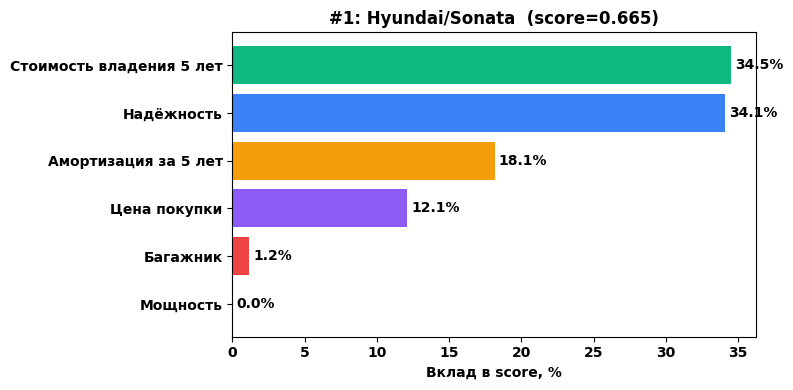

In [4]:
decomp = result.decompositions[0]
labels = [c['label_ru'] for c in decomp['contributions']]
shares = [c['share'] * 100 for c in decomp['contributions']]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(labels, shares, color=['#10b981','#3b82f6','#f59e0b','#8b5cf6','#ef4444','#14b8a6'])
ax.set_xlabel('Вклад в score, %')
top_row = result.top.iloc[0]
ax.set_title(f'#1: {top_row["make_name"]}/{top_row["model_name"]}  (score={decomp["rank_score"]:.3f})')
ax.invert_yaxis()
for i, v in enumerate(shares):
    ax.text(v + 0.3, i, f'{v:.1f}%', va='center')
plt.tight_layout()
plt.show()

## 4. NDCG@10 / Diversity по всем 12 кейсам

In [5]:
def ndcg_at_k(rels, k=10):
    rels = rels[:k]
    if not any(rels):
        return 0.0
    dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rels))
    sorted_rels = sorted(rels, reverse=True)
    idcg = sum(r / np.log2(i + 2) for i, r in enumerate(sorted_rels))
    return dcg / idcg if idcg > 0 else 0.0

def parse_gt(v):
    return {x.strip() for x in str(v).split(';') if x.strip()} if not pd.isna(v) else set()

results = []
for _, case in cases.iterrows():
    profile = build_profile(case)
    r = service.recommend(catalog, profile, top_k=10)
    gt_top = parse_gt(case['ground_truth_top3'])
    gt_acc = parse_gt(case['ground_truth_acceptable'])
    rels = []
    keys = []
    for _, row in r.top.iterrows():
        k = f'{row["make_name"]}/{row["model_name"]}'
        keys.append(k)
        if k in gt_top: rels.append(3)
        elif k in gt_acc: rels.append(2)
        else: rels.append(0)
    results.append({
        'case_id': case['case_id'],
        'description': case['description'][:35],
        'after_filters': r.n_after_filters,
        'ndcg_10': ndcg_at_k(rels, 10),
        'diversity_10': r.top['make_name'].nunique() if len(r.top) else 0,
        'top3_hits': sum(1 for x in rels if x == 3),
        'accpt_hits': sum(1 for x in rels if x == 2),
    })
metrics_df = pd.DataFrame(results)
metrics_df

,case_id,description,after_filters,ndcg_10,diversity_10,top3_hits,accpt_hits
0,1,Студент-городской бюджет 1.5М,23,0.921454,2,2,8
1,2,Семья 4 чел С-класс mass,38,0.969564,8,3,3
2,3,Семья + дача кроссовер,211,0.811837,5,0,7
3,4,Премиум седан Е,15,0.929520,8,1,9
4,5,Премиум SUV J_CROSS,60,0.965137,8,0,6
5,6,Off-road рамный SUV,17,1.000000,5,0,2
6,7,Минивэн 7+ мест,17,0.836385,8,4,5
7,8,Студент-китаист бюджетный кроссовер,58,0.703193,7,0,6
8,9,Pickup для бизнеса,22,0.976543,5,5,5
9,10,Корпоративный седан C/D,13,0.885345,7,1,4


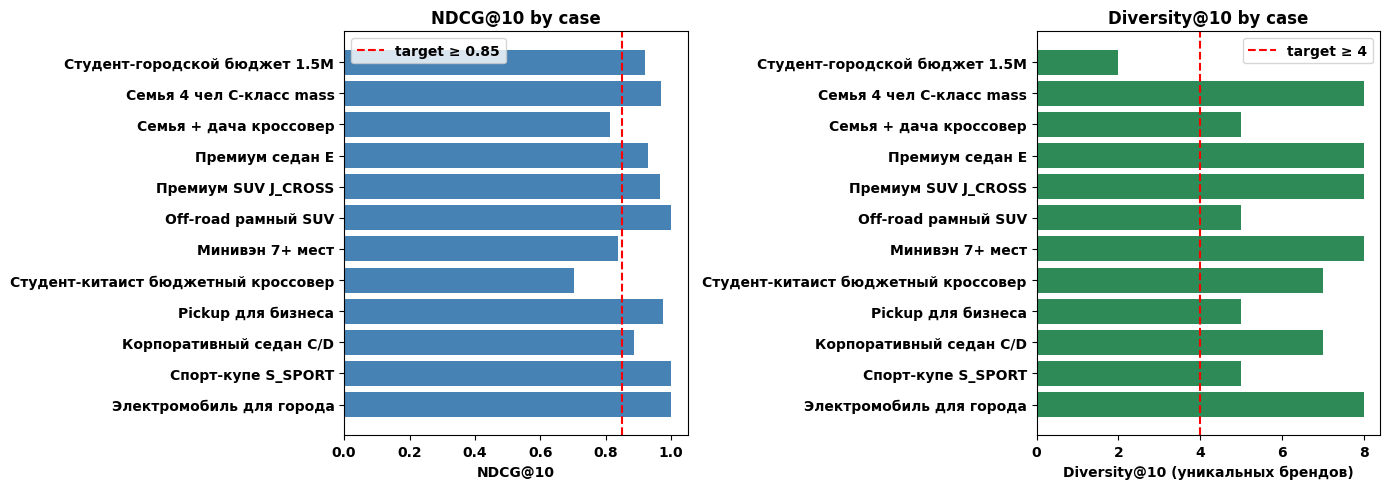

NDCG@10:           median=0.947  mean=0.917
Diversity@10:      median=7  mean=6.3


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.barh(metrics_df['description'], metrics_df['ndcg_10'], color='steelblue')
ax1.axvline(x=0.85, color='red', linestyle='--', label='target ≥ 0.85')
ax1.set_xlabel('NDCG@10')
ax1.set_title('NDCG@10 by case')
ax1.invert_yaxis()
ax1.legend()

ax2.barh(metrics_df['description'], metrics_df['diversity_10'], color='seagreen')
ax2.axvline(x=4, color='red', linestyle='--', label='target ≥ 4')
ax2.set_xlabel('Diversity@10 (уникальных брендов)')
ax2.set_title('Diversity@10 by case')
ax2.invert_yaxis()
ax2.legend()

plt.tight_layout()
plt.show()

print(f'NDCG@10:           median={metrics_df["ndcg_10"].median():.3f}  mean={metrics_df["ndcg_10"].mean():.3f}')
print(f'Diversity@10:      median={int(metrics_df["diversity_10"].median())}  mean={metrics_df["diversity_10"].mean():.1f}')

## 5. Sensitivity к выбору strategy: TOPSIS vs WSM

Сравнение топ-10 двух стратегий. Высокое перекрытие = алгоритмы согласованы, низкое = критичная зависимость от выбора метода.

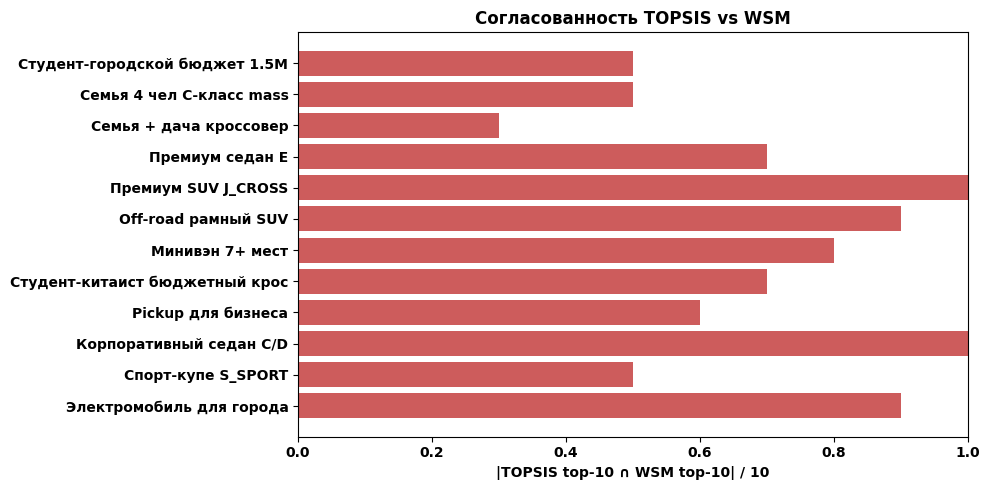

Overlap median = 0.70; mean = 0.70


In [7]:
wsm_service = RecommendationService(tco_calc=calc, strategy=WeightedSumStrategy())

overlaps = []
for _, case in cases.iterrows():
    profile = build_profile(case)
    r_topsis = service.recommend(catalog, profile, top_k=10)
    r_wsm = wsm_service.recommend(catalog, profile, top_k=10)
    keys_t = {f'{row["make_name"]}/{row["model_name"]}' for _, row in r_topsis.top.iterrows()}
    keys_w = {f'{row["make_name"]}/{row["model_name"]}' for _, row in r_wsm.top.iterrows()}
    if not keys_t or not keys_w:
        ov = 0.0
    else:
        ov = len(keys_t & keys_w) / 10
    overlaps.append({'case_id': case['case_id'], 'desc': case['description'][:30], 'overlap': ov})

ov_df = pd.DataFrame(overlaps)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ov_df['desc'], ov_df['overlap'], color='indianred')
ax.set_xlabel('|TOPSIS top-10 ∩ WSM top-10| / 10')
ax.set_title('Согласованность TOPSIS vs WSM')
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(f'Overlap median = {ov_df["overlap"].median():.2f}; mean = {ov_df["overlap"].mean():.2f}')

## 6. Stability к колебанию весов ±5%

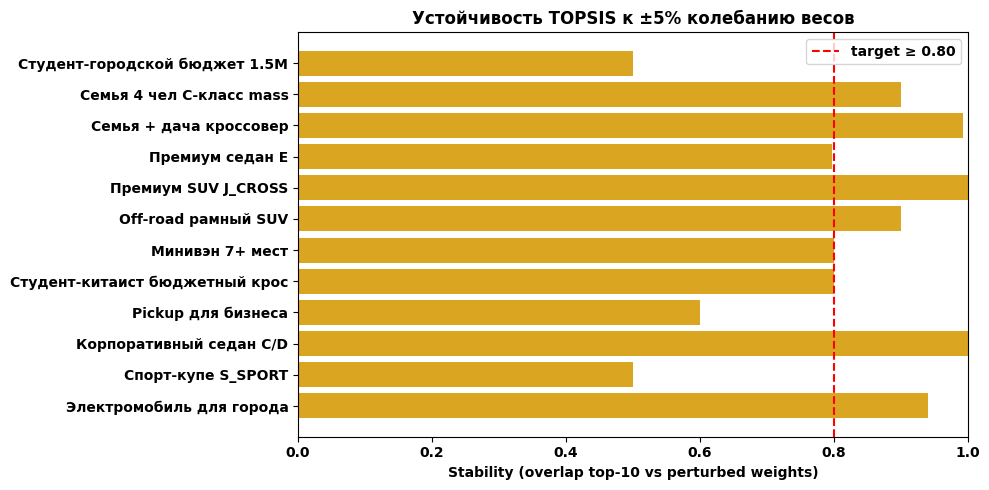

Stability median = 0.850;  mean = 0.811


In [8]:
def stability(case_row, n_iter=30, eps=0.05, seed=42):
    profile = build_profile(case_row)
    base_w = profile.resolve_weights()
    augmented = service._augment_catalog(catalog)
    filtered = service._apply_filters(augmented, build_filters_from_profile(profile))
    if len(filtered) == 0: return 0.0
    with_crit = service._compute_dynamic_criteria(filtered, profile)
    base_top = service.strategy.rank(with_crit, base_w, service.criteria).head(10)
    base_keys = {f'{row["make_name"]}/{row["model_name"]}' for _, row in base_top.iterrows()}
    rng = np.random.default_rng(seed)
    overlaps = []
    for _ in range(n_iter):
        pert = {k: v * (1 + rng.uniform(-eps, eps)) for k, v in base_w.items()}
        s = sum(pert.values())
        pert = {k: v / s for k, v in pert.items()}
        ranked = service.strategy.rank(with_crit, pert, service.criteria).head(10)
        keys = {f'{row["make_name"]}/{row["model_name"]}' for _, row in ranked.iterrows()}
        overlaps.append(len(keys & base_keys) / 10)
    return float(np.mean(overlaps))

stab = []
for _, case in cases.iterrows():
    s = stability(case)
    stab.append({'case_id': case['case_id'], 'desc': case['description'][:30], 'stability': s})

stab_df = pd.DataFrame(stab)
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(stab_df['desc'], stab_df['stability'], color='goldenrod')
ax.axvline(x=0.80, color='red', linestyle='--', label='target ≥ 0.80')
ax.set_xlabel('Stability (overlap top-10 vs perturbed weights)')
ax.set_title('Устойчивость TOPSIS к ±5% колебанию весов')
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend()
plt.tight_layout()
plt.show()
print(f'Stability median = {stab_df["stability"].median():.3f};  mean = {stab_df["stability"].mean():.3f}')

## 7. Итоговая сводка

In [9]:
summary = pd.DataFrame({
    'metric': ['NDCG@10 (median)', 'Diversity@10 (median)', 'Stability (median)'],
    'value': [metrics_df['ndcg_10'].median(), metrics_df['diversity_10'].median(), stab_df['stability'].median()],
    'target': [0.85, 4, 0.80],
})
summary['pass'] = summary['value'] >= summary['target']
summary

,metric,value,target,pass
0,NDCG@10 (median),0.947329,0.85,True
1,Diversity@10 (median),7.000000,4.00,True
2,Stability (median),0.850000,0.80,True
